In [1]:
import scanpy as sc
import anndata as ad
import scib
import matplotlib.pyplot as plt
import pandas as pd

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# load in dataset
adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata.h5ad")

In [3]:
## Benchmark with coarse cell-type labels
batch_key = "dataset" 
label_key = "celltypist_cell_label_coarse"

# need to recompute neighbours for each embedding (for graph_conn metric), consider redoing integration with new adatas per method to make this cleaner
def metrics_with_neighbors(adata, batch_key, label_key, embed):
    """Recompute default neighbours from `embed` so graph_conn reflects the method."""
    sc.pp.neighbors(adata, use_rep=embed)   # writes to default slot
    return scib.metrics.metrics_fast(adata, adata, batch_key, label_key, embed=embed)

metrics_scvi      = metrics_with_neighbors(adata, batch_key, label_key, "X_scVI")
metrics_scanvi    = metrics_with_neighbors(adata, batch_key, label_key, "X_scANVI")
metrics_harmony   = metrics_with_neighbors(adata, batch_key, label_key, "X_pca_harmony")
metrics_scanorama = metrics_with_neighbors(adata, batch_key, label_key, "X_scanorama")
metrics_unintegrated = metrics_with_neighbors(adata, batch_key, label_key, "X_pca")

# BBKNN: restore the saved BBKNN graph to default slot, then run without embed=
adata.uns["neighbors"]       = adata.uns["bbknn"].copy()
adata.obsp["distances"]      = adata.obsp["distances_bbknn"].copy()
adata.obsp["connectivities"] = adata.obsp["connectivities_bbknn"].copy()
metrics_bbknn = scib.metrics.metrics_fast(adata, adata, batch_key, label_key)

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Silhouette score...


PC regression...


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})


Isolated labels ASW...


...

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hvg_dir[i.obs[batch][0]] = i.var.index[hvg["highly_variable"]]


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hvg_dir[i.obs[batch][0]] = i.var.index[hvg["highly_variable"]]


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  batch_var = ad_post.obs[batch_key][0]


/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  batch_var = ad_post.obs[batch_key][0]


In [4]:
# plot all metrics together for comparison

# Concatenate metrics results
metrics = pd.concat(
    [metrics_scvi, metrics_scanvi, metrics_harmony, metrics_scanorama, metrics_bbknn, metrics_unintegrated],
    axis="columns",
)
# Set methods as column names
metrics = metrics.set_axis(
    ["scVI", "scANVI", "Harmony", "Scanorama", "BBKNN", "Unintegrated"], axis="columns"
)
# Select only the fast metrics
metrics = metrics.loc[
    [
        "ASW_label",
        "ASW_label/batch",
        "PCR_batch",
        "isolated_label_silhouette",
        "graph_conn",
        "hvg_overlap",
    ],
    :,
]
# Transpose so that metrics are columns and methods are rows
metrics = metrics.T
# Remove the HVG overlap metric because it's not relevant to embedding outputs
metrics = metrics.drop(columns=["hvg_overlap"])
metrics

,ASW_label,ASW_label/batch,PCR_batch,isolated_label_silhouette,graph_conn
scVI,0.604499,0.885951,0.896477,0.633451,0.938418
scANVI,0.636318,0.875894,0.896465,0.651611,0.944308
Harmony,0.572155,0.877230,0.902020,0.566814,0.983596
Scanorama,0.551671,0.845759,0.485503,0.679453,0.973588
BBKNN,0.545871,0.696103,0.000000,0.674326,0.992065
Unintegrated,0.545871,0.696103,0.000000,0.674326,0.929704


In [5]:
metrics.style.background_gradient(cmap="Blues")

,ASW_label,ASW_label/batch,PCR_batch,isolated_label_silhouette,graph_conn
scVI,0.604499,0.885951,0.896477,0.633451,0.938418
scANVI,0.636318,0.875894,0.896465,0.651611,0.944308
Harmony,0.572155,0.877230,0.902020,0.566814,0.983596
Scanorama,0.551671,0.845759,0.485503,0.679453,0.973588
BBKNN,0.545871,0.696103,0.000000,0.674326,0.992065
Unintegrated,0.545871,0.696103,0.000000,0.674326,0.929704


In [6]:
# Scale 0–1 across methods to emphasise differences
metrics_scaled = (metrics - metrics.min()) / (metrics.max() - metrics.min())
metrics_scaled.style.background_gradient(cmap="Blues")

,ASW_label,ASW_label/batch,PCR_batch,isolated_label_silhouette,graph_conn
scVI,0.648205,1.000000,0.993855,0.591593,0.139735
scANVI,1.000000,0.947024,0.993842,0.752819,0.234192
Harmony,0.290600,0.954062,1.000000,0.000000,0.864187
Scanorama,0.064119,0.788295,0.538240,1.000000,0.703714
BBKNN,0.000000,0.000000,0.000000,0.954485,1.000000
Unintegrated,0.000000,0.000000,0.000000,0.954485,0.000000


In [7]:
# Group into Batch correction vs Biological conservation summaries
metrics_scaled["Batch"] = metrics_scaled[
    ["ASW_label/batch", "PCR_batch", "graph_conn"]
].mean(axis=1)
metrics_scaled["Bio"] = metrics_scaled[
    ["ASW_label", "isolated_label_silhouette"]
].mean(axis=1)
metrics_scaled.style.background_gradient(cmap="Blues")

,ASW_label,ASW_label/batch,PCR_batch,isolated_label_silhouette,graph_conn,Batch,Bio
scVI,0.648205,1.000000,0.993855,0.591593,0.139735,0.711197,0.619899
scANVI,1.000000,0.947024,0.993842,0.752819,0.234192,0.725019,0.876409
Harmony,0.290600,0.954062,1.000000,0.000000,0.864187,0.939416,0.145300
Scanorama,0.064119,0.788295,0.538240,1.000000,0.703714,0.676750,0.532060
BBKNN,0.000000,0.000000,0.000000,0.954485,1.000000,0.333333,0.477243
Unintegrated,0.000000,0.000000,0.000000,0.954485,0.000000,0.000000,0.477243


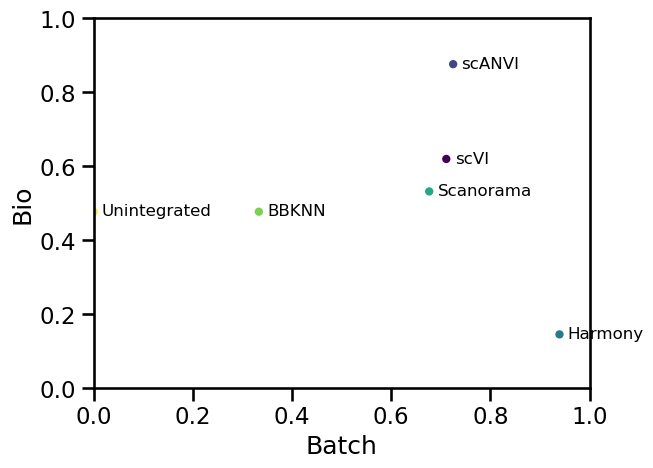

In [8]:
# Scatter: Batch vs Bio trade-off
fig, ax = plt.subplots()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
metrics_scaled.plot.scatter(
    x="Batch",
    y="Bio",
    c=range(len(metrics_scaled)),
    ax=ax,
)
for k, v in metrics_scaled[["Batch", "Bio"]].iterrows():
    ax.annotate(
        k, v,
        xytext=(6, -3), textcoords="offset points",
        family="sans-serif", fontsize=12,
    )
plt.show()

In [9]:
# Weighted overall score (40 % batch, 60 % bio per scIB paper)
metrics_scaled["Overall"] = (
    0.4 * metrics_scaled["Batch"] + 0.6 * metrics_scaled["Bio"]
)
metrics_scaled.style.background_gradient(cmap="Blues")

,ASW_label,ASW_label/batch,PCR_batch,isolated_label_silhouette,graph_conn,Batch,Bio,Overall
scVI,0.648205,1.000000,0.993855,0.591593,0.139735,0.711197,0.619899,0.656418
scANVI,1.000000,0.947024,0.993842,0.752819,0.234192,0.725019,0.876409,0.815853
Harmony,0.290600,0.954062,1.000000,0.000000,0.864187,0.939416,0.145300,0.462947
Scanorama,0.064119,0.788295,0.538240,1.000000,0.703714,0.676750,0.532060,0.589936
BBKNN,0.000000,0.000000,0.000000,0.954485,1.000000,0.333333,0.477243,0.419679
Unintegrated,0.000000,0.000000,0.000000,0.954485,0.000000,0.000000,0.477243,0.286346


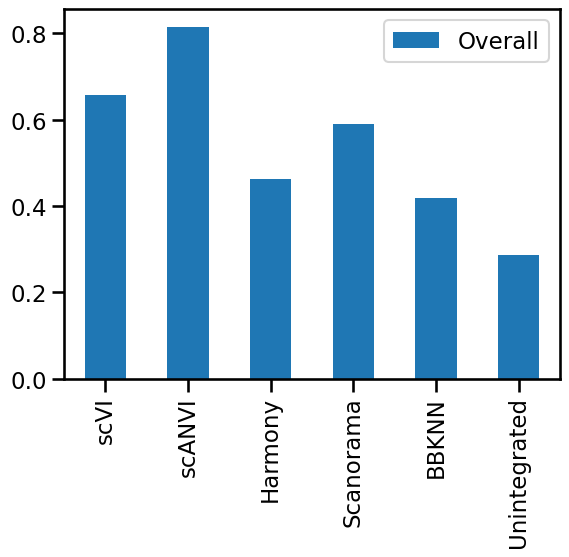

In [10]:
# Bar chart of overall ranking
metrics_scaled.plot.bar(y="Overall")
plt.show()

In [11]:
# ## Benchmark with fine cell-type labels
# label_key = "celltypist_cell_label_fine"

# metrics_scvi      = metrics_with_neighbors(adata, batch_key, label_key, "X_scVI")
# metrics_scanvi    = metrics_with_neighbors(adata, batch_key, label_key, "X_scANVI")
# metrics_harmony   = metrics_with_neighbors(adata, batch_key, label_key, "X_pca_harmony")
# metrics_scanorama = metrics_with_neighbors(adata, batch_key, label_key, "X_scanorama")
# metrics_unintegrated = metrics_with_neighbors(adata, batch_key, label_key, "X_pca")

# # BBKNN: restore the saved BBKNN graph to default slot, then run without embed=
# adata.uns["neighbors"]       = adata.uns["bbknn"].copy()
# adata.obsp["distances"]      = adata.obsp["distances_bbknn"].copy()
# adata.obsp["connectivities"] = adata.obsp["connectivities_bbknn"].copy()
# metrics_bbknn = scib.metrics.metrics_fast(adata, adata, batch_key, label_key)


In [12]:
# # plot all metrics together for comparison

# # Concatenate metrics results
# metrics = pd.concat(
#     [metrics_scvi, metrics_scanvi, metrics_harmony, metrics_scanorama, metrics_bbknn, metrics_unintegrated],
#     axis="columns",
# )
# # Set methods as column names
# metrics = metrics.set_axis(
#     ["scVI", "scANVI", "Harmony", "Scanorama", "BBKNN", "Unintegrated"], axis="columns"
# )
# # Select only the fast metrics
# metrics = metrics.loc[
#     [
#         "ASW_label",
#         "ASW_label/batch",
#         "PCR_batch",
#         "isolated_label_silhouette",
#         "graph_conn",
#         "hvg_overlap",
#     ],
#     :,
# ]
# # Transpose so that metrics are columns and methods are rows
# metrics = metrics.T
# # Remove the HVG overlap metric because it's not relevant to embedding outputs
# metrics = metrics.drop(columns=["hvg_overlap"])
# metrics

In [13]:
# metrics.style.background_gradient(cmap="Blues")

In [14]:
# # Scale 0–1 across methods to emphasise differences
# metrics_scaled = (metrics - metrics.min()) / (metrics.max() - metrics.min())
# metrics_scaled.style.background_gradient(cmap="Blues")

In [15]:
# # Group into Batch correction vs Biological conservation summaries
# metrics_scaled["Batch"] = metrics_scaled[
#     ["ASW_label/batch", "PCR_batch", "graph_conn"]
# ].mean(axis=1)
# metrics_scaled["Bio"] = metrics_scaled[
#     ["ASW_label", "isolated_label_silhouette"]
# ].mean(axis=1)
# metrics_scaled.style.background_gradient(cmap="Blues")

In [16]:
# # Scatter: Batch vs Bio trade-off
# fig, ax = plt.subplots()
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
# metrics_scaled.plot.scatter(
#     x="Batch",
#     y="Bio",
#     c=range(len(metrics_scaled)),
#     ax=ax,
# )
# for k, v in metrics_scaled[["Batch", "Bio"]].iterrows():
#     ax.annotate(
#         k, v,
#         xytext=(6, -3), textcoords="offset points",
#         family="sans-serif", fontsize=12,
#     )
# plt.show()

In [17]:
# # Weighted overall score (40 % batch, 60 % bio per scIB paper)
# metrics_scaled["Overall"] = (
#     0.4 * metrics_scaled["Batch"] + 0.6 * metrics_scaled["Bio"]
# )
# metrics_scaled.style.background_gradient(cmap="Blues")

In [18]:
# # Bar chart of overall ranking
# metrics_scaled.plot.bar(y="Overall")
# plt.show()